In [1]:
import numpy as np
import matplotlib.pyplot as plt

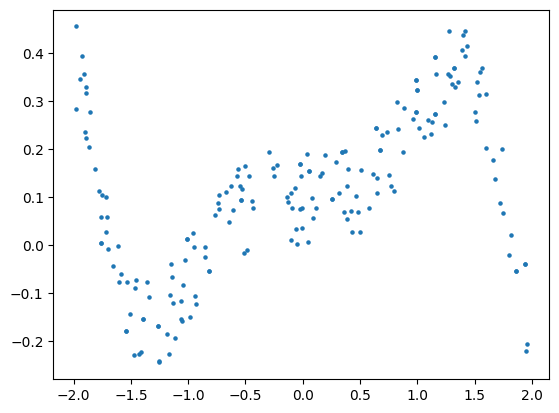

In [26]:
x = np.linspace(-2, 2, 1000)

y = np.sin(x**2)*x*.2 + np.random.rand(x.shape[0])*.2

train_indices = np.random.randint(0, 1000, size=200)
x_train = x[train_indices].reshape(-1, 1)
y_train = y[train_indices]

plt.scatter(x_train, y_train, s=5)

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=2)
dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=2)

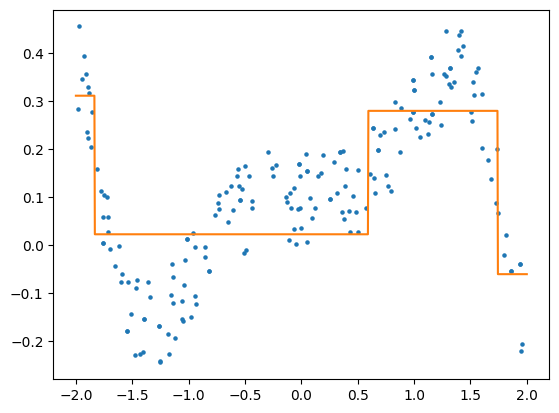

In [37]:
y_preds_total = dt.predict(x.reshape(-1, 1))

plt.scatter(x_train, y_train, s=5)
plt.plot(x, y_preds_total, color='C1')

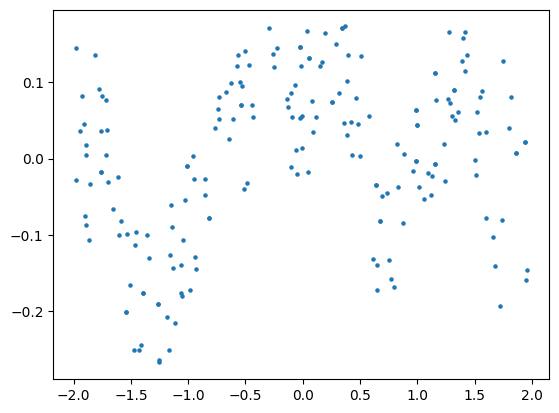

In [38]:
y_preds = dt.predict(x_train)

residuals = y_train - y_preds

plt.scatter(x_train, residuals, s=5)

In [39]:
dt2 = DecisionTreeRegressor(max_depth=2)
dt2.fit(x_train, residuals)

DecisionTreeRegressor(max_depth=2)

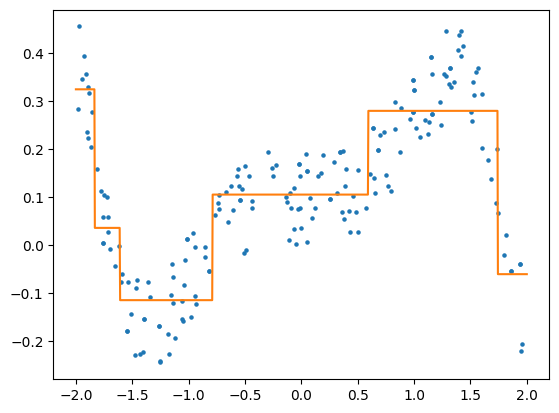

In [40]:
y_preds_total = dt.predict(x.reshape(-1, 1)) + dt2.predict(x.reshape(-1, 1))

plt.scatter(x_train, y_train, s=5)
plt.plot(x, y_preds_total, color='C1')

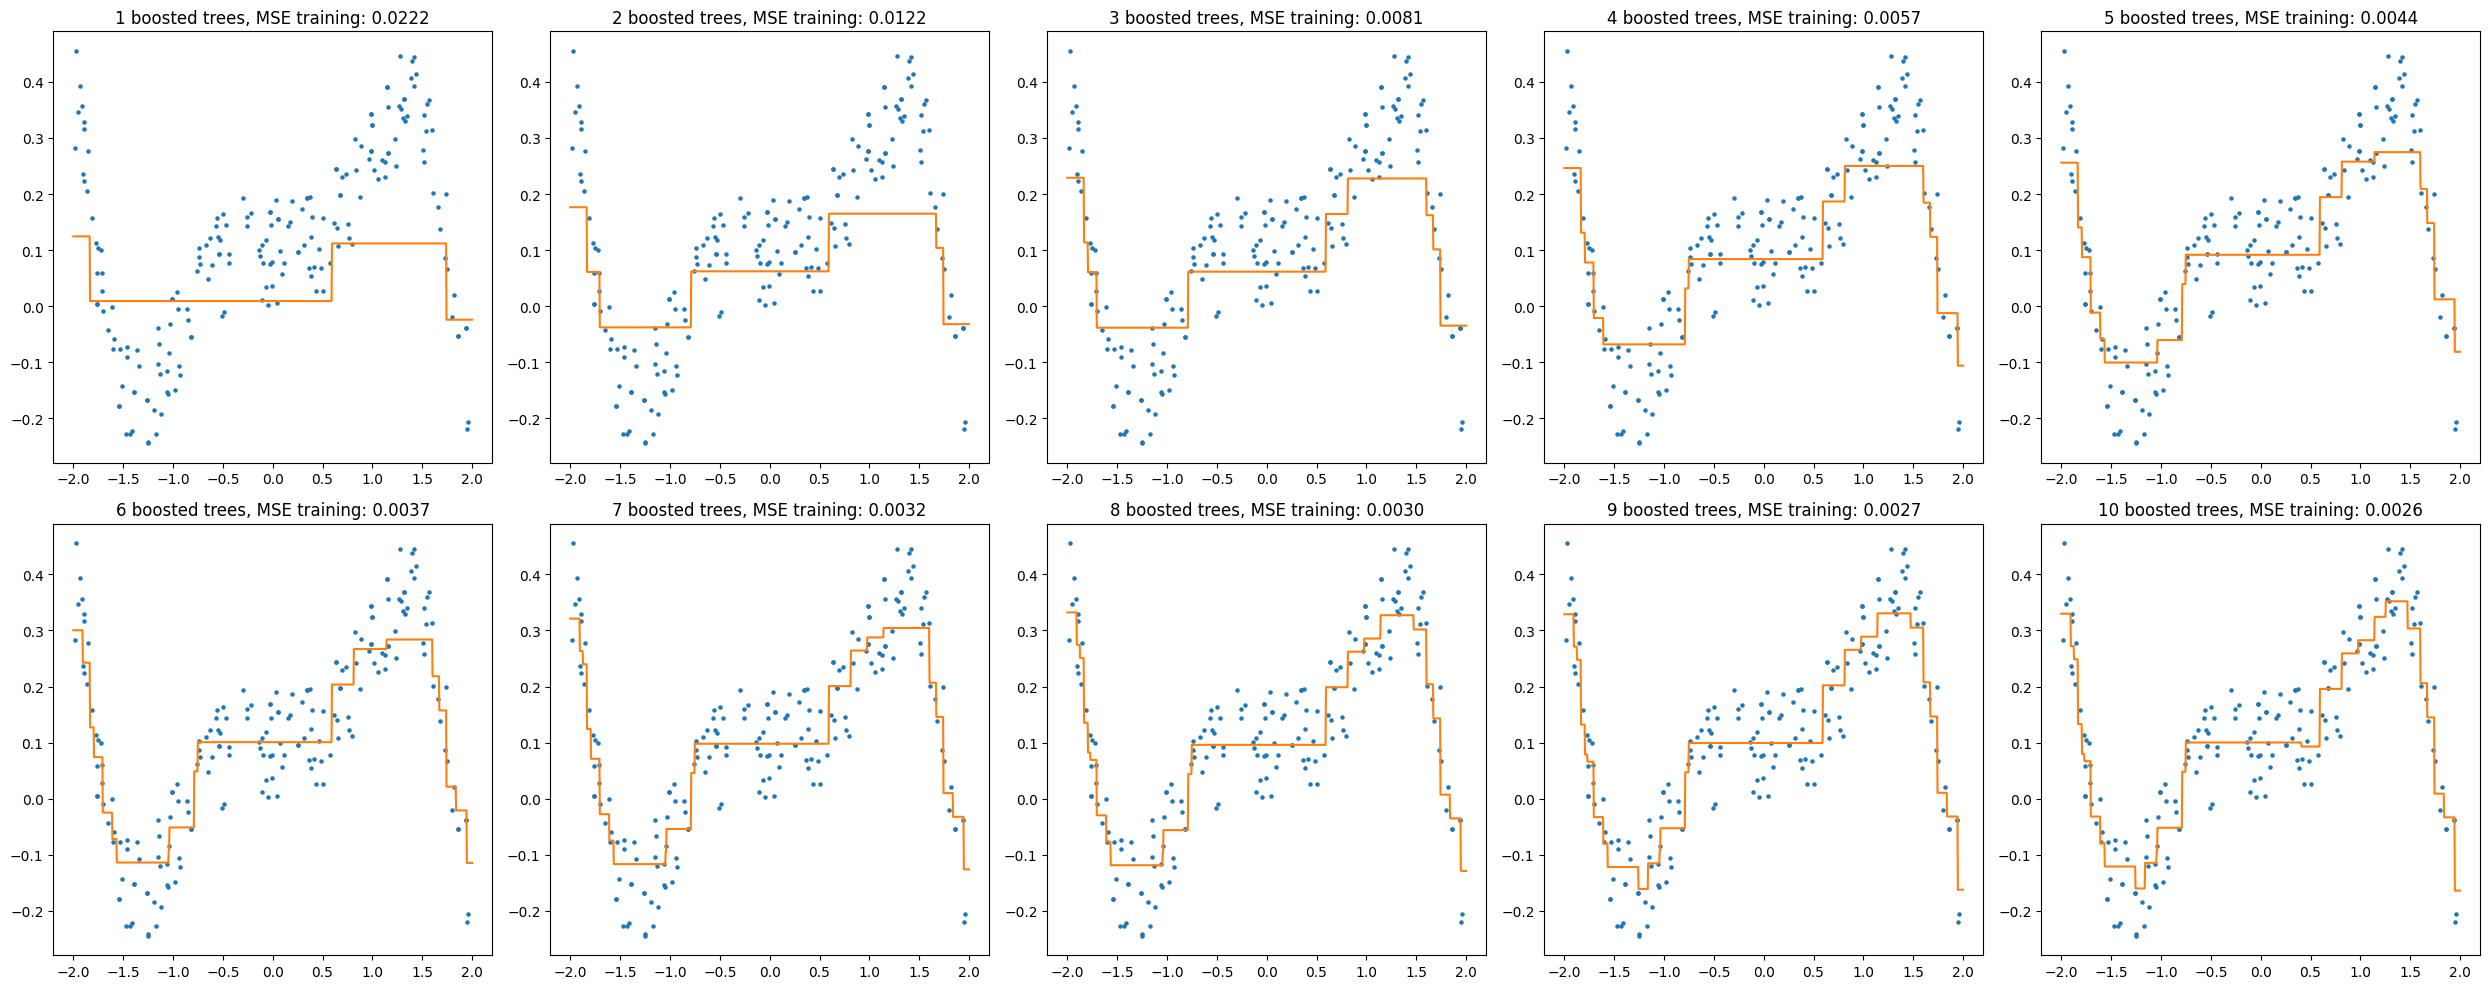

In [62]:
trees = []
n_boosts = 10
learning_rate = 0.4
residuals = y_train

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i in range(n_boosts):
    
    # train decision tree on residuals
    dt = DecisionTreeRegressor(max_depth=2)
    dt.fit(x_train, residuals)
    
    # make prediction scaled by learning rate
    trees.append(dt)
    y_preds = learning_rate * sum([tree.predict(x_train) for tree in trees])

    # update residuals
    residuals = y_train - y_preds

    # visualize
    y_preds_total = learning_rate * sum([tree.predict(x.reshape(-1, 1)) for tree in trees])
    mse = np.mean(residuals**2)
    axes[i].scatter(x_train, y_train, s=5)
    axes[i].plot(x, y_preds_total, color='C1')
    axes[i].set_title(f"{i+1} boosted trees, MSE training: {mse:.4f}")

plt.tight_layout()

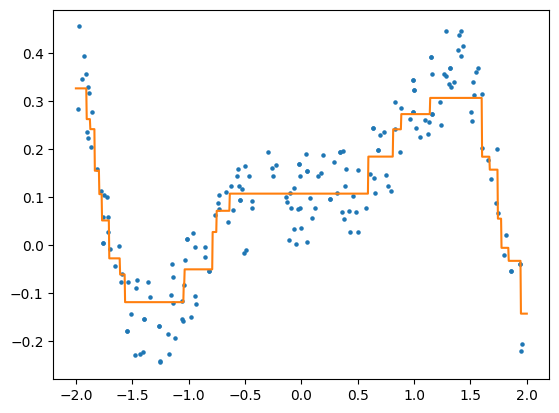

In [59]:
y_preds_total = learning_rate * sum([tree.predict(x.reshape(-1, 1)) for tree in trees])

plt.scatter(x_train, y_train, s=5)
plt.plot(x, y_preds_total, color='C1')